In [2]:
import argparse  
import os
import pickle
import gzip
import fnmatch

import awkward as ak
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from cycler import cycler
import mplhep as hep

import hist
from hist import Hist

from topcoffea.modules.histEFT import HistEFT
from topcoffea.modules import utils
import topcoffea.modules.eft_helper as efth

from ttbarEFT.modules import plotting_tools_histEFT as plt_tools

In [3]:
def load_pkl(fname):
    hists = pickle.load(gzip.open(fname))
    return hists

In [11]:
djr_hists = load_pkl("djr.pkl.gz")
print(djr_hists.keys())

dict_keys(['djr_10_all', 'djr_10_0p', 'djr_10_1p'])


In [10]:
wc_list = list(djr_hists['djr_10_all']._wc_names.keys())
SM_rwgt = {'cQd1':0, 'ctj1':0, 'cQj31':0, 'ctj8':0, 
           'ctd1':0, 'ctd8':0, 'ctGRe':0, 'ctGIm':0,
           'cQj11':0, 'cQj18':0, 'ctu8':0, 'cQd8':0,
           'ctu1':0, 'cQu1':0, 'cQj38':0, 'cQu8':0,
            }
stpt_rwgt = {'cQd1':1.5, 'ctj1':1.5, 'cQj31':1.5, 'ctj8':1.5, 
           'ctd1':1.5, 'ctd8':1.5, 'ctGRe':-0.5, 'ctGIm':-0.5,
           'cQj11':1.5, 'cQj18':1.5, 'ctu8':1.5, 'cQd8':1.5,
           'ctu1':1.5, 'cQu1':1.5, 'cQj38':1.5, 'cQu8':1.5,
            }
large_rwgt = {'cQd1':3, 'ctj1':4, 'cQj31':2, 'ctj8':6, 
           'ctd1':4, 'ctd8':3, 'ctGRe':2, 'ctGIm':-2,
           'cQj11':3, 'cQj18':2, 'ctu8':3, 'cQd8':6,
           'ctu1':1, 'cQu1':3, 'cQj38':5, 'cQu8':8,
            }

In [13]:
rwgt = SM_rwgt
djr_hists['djr_10_all'].as_hist(rwgt).project(

Hist(Regular(80, 0, 4, name='djr_10_all', label='DJR  0 to 1'), storage=Double()) # Sum: 22765580.714970954 (22855697.8576845 with flow)

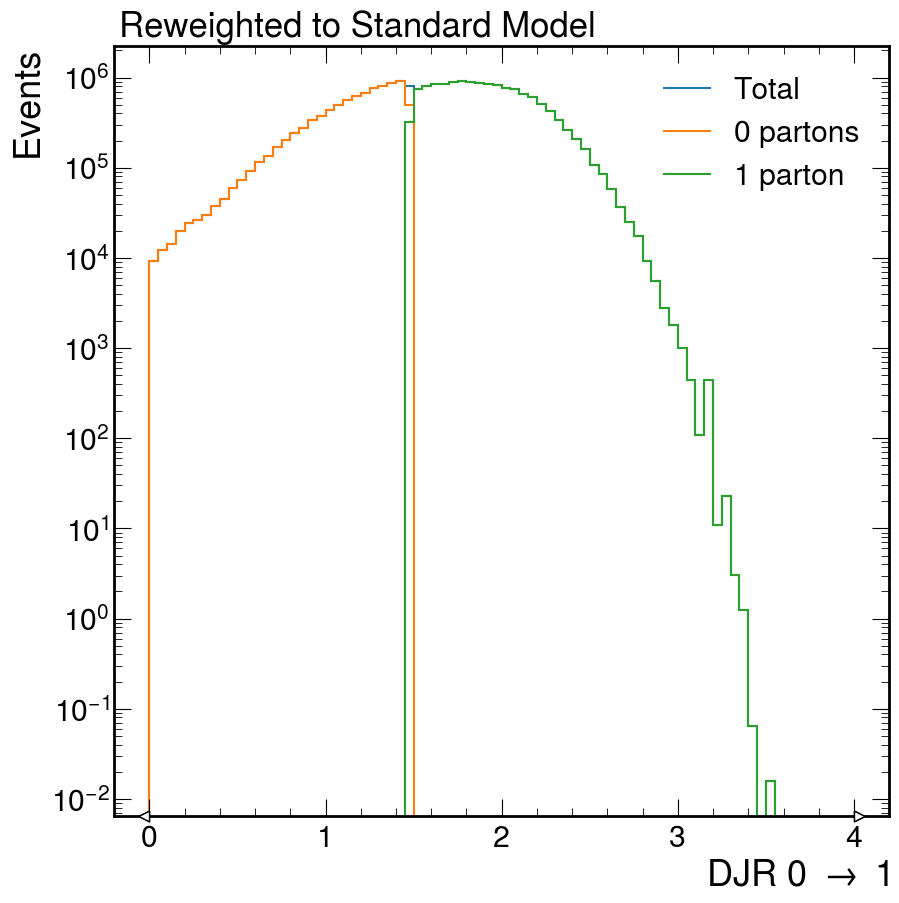

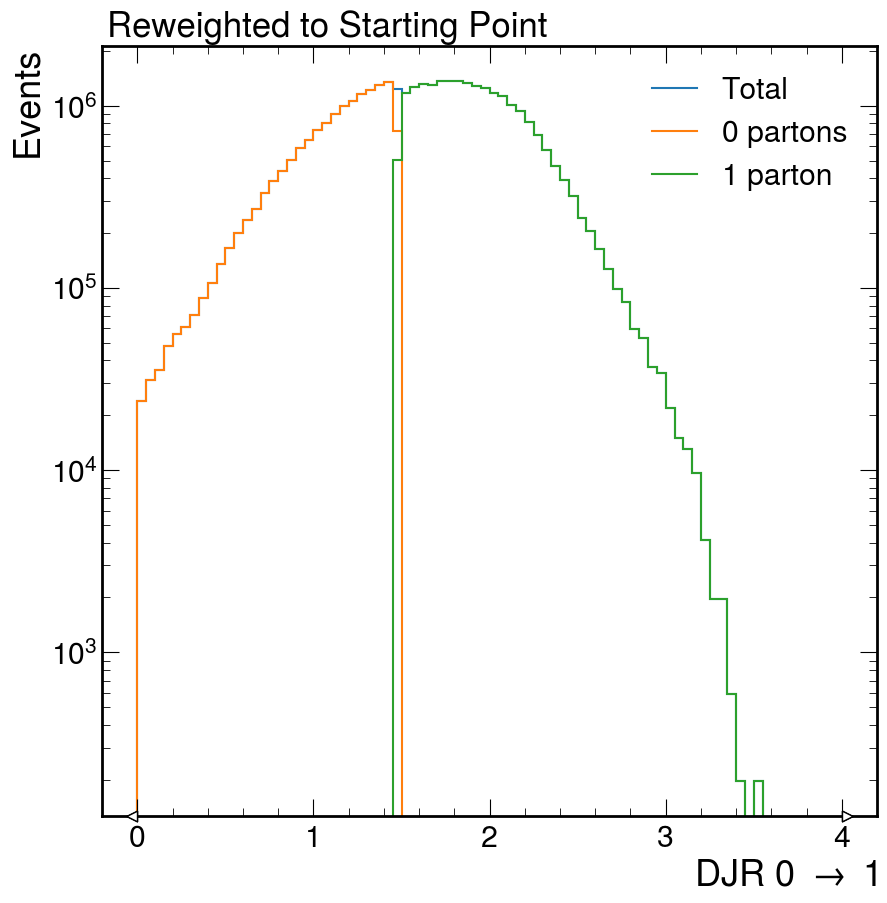

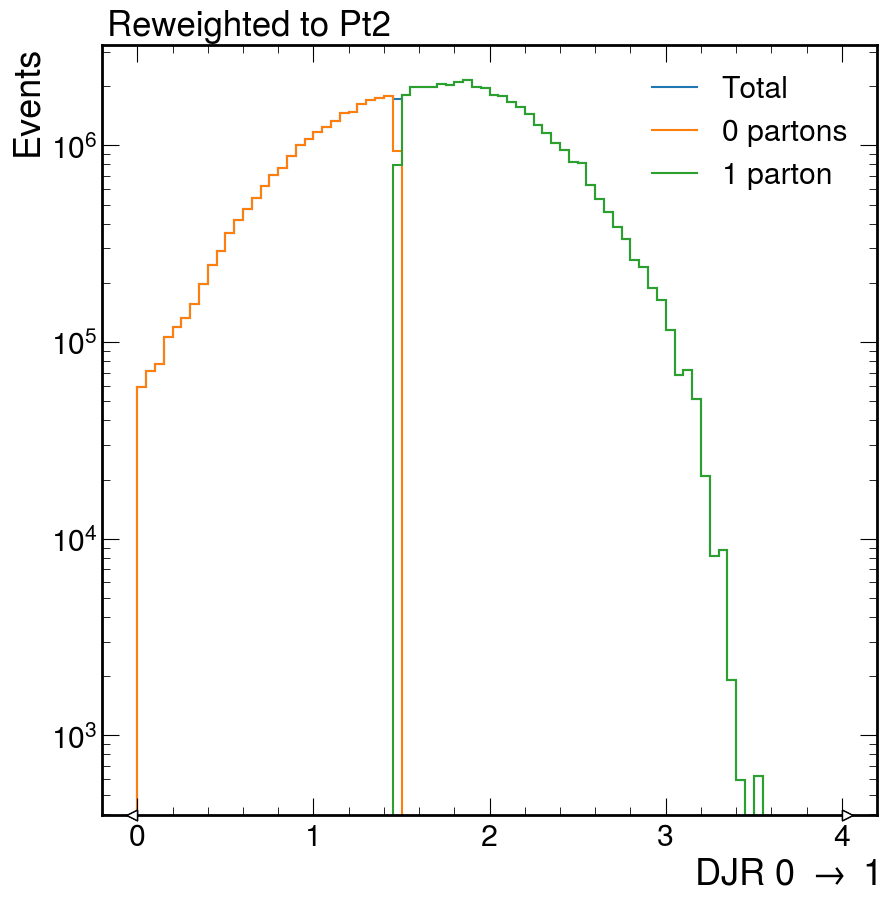

In [26]:
plots = {
    'Reweighted to Standard Model': SM_rwgt,
    'Reweighted to Starting Point': stpt_rwgt,
    'Reweighted to Pt2': large_rwgt,
}

for plot in plots: 
    hep.style.use("CMS")
    fig, ax = plt.subplots(1,1)

    hep.histplot(
            djr_hists['djr_10_all'].as_hist(plots[plot]).project('djr_10_all'),
            stack=True,
            histtype="step",
            # linewidth=2,
            yerr=False,
            ax=ax,
            label="Total",
            color="tab:blue"
        )
        
    hep.histplot(
            djr_hists['djr_10_0p'].as_hist(plots[plot]).project('djr_10_0p'),
            stack=True,
            histtype="step",
            # linewidth=2,
            yerr=False,
            ax=ax,
            label="0 partons",
            color="tab:orange"
        )
    hep.histplot(
            djr_hists['djr_10_1p'].as_hist(plots[plot]).project('djr_10_1p'),
            stack=True,
            histtype="step",
            # linewidth=2,
            yerr=False,
            ax=ax,
            label="1 parton",
            color="tab:green"
        )

    ax.legend()
    ax.set_yscale('log')
    ax.set_xlabel(r"DJR 0 $\rightarrow$ 1")
    ax.set_ylabel("Events")
    plt.figtext(0.13, 0.89, plot, fontsize=25)
    # plt_tools.save_figure(fig, "DJR_largeWC")

In [ ]:
# h = hists["djr_10_all"]
# h0 = hists["djr_10_0p"]
# h1 = hists["djr_10_1p"]
# h.set_sm()
# h0.set_sm()
# h1.set_sm()

# fig, ax = plt.subplots(1,1)
# ax.set_yscale('log')

# hist.plot1d(h, stack=False)
# hist.plot1d(h0, stack=False)
# hist.plot1d(h1, stack=False)

# ax.set_xlabel(r"DJR 0 $\rightarrow$ 1")
# ax.legend(["Total", "0 partons", "1 parton"])
# plt.figtext(0.13, 0.89, title, fontsize=25)

# figname = label+'_sm_djr01'